# 🎬 Project 3 — Analyzing and Visualizing Movie Ratings

**Tasks Covered:**
1. 🧹 Clean and preprocess the data
2. 📊 Calculate summary statistics (mean, median, mode)
3. 📈 Visualize distribution of ratings (histogram, box plot)
4. 🏆 Identify top-rated movies and genres
5. 🖥️ Create a summary dashboard

**Dataset:** Simulated IMDB-style movie dataset (easily replaceable with real CSV)

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Global Plot Style ────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#F7F9FC',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'font.size'        : 11,
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
})

PALETTE = sns.color_palette('Set2', 10)

print('✅  Libraries loaded successfully!')

✅  Libraries loaded successfully!


---
## 2. Load / Create Dataset
> **To use your own data:** Replace the cell below with `df = pd.read_csv('your_file.csv')`  
> Expected columns: `title`, `genre`, `year`, `rating`, `votes`, `duration_min`, `director`

In [2]:
np.random.seed(42)
N = 500

GENRES = ['Action','Comedy','Drama','Thriller','Romance',
          'Sci-Fi','Horror','Animation','Documentary','Crime']

DIRECTORS = ['Christopher Nolan','Steven Spielberg','Martin Scorsese',
             'Quentin Tarantino','James Cameron','Ridley Scott',
             'David Fincher','Peter Jackson','Denis Villeneuve','Wes Anderson']

# Genre-specific rating biases (so genres feel realistic)
genre_bias = {
    'Drama':7.1,'Crime':7.0,'Documentary':7.2,'Animation':7.3,
    'Sci-Fi':6.9,'Thriller':6.8,'Action':6.5,'Comedy':6.4,
    'Romance':6.2,'Horror':5.9
}

genres     = np.random.choice(GENRES, N)
base_rat   = np.array([genre_bias[g] for g in genres])
ratings    = np.clip(base_rat + np.random.normal(0, 1.0, N), 1.0, 10.0).round(1)

# Inject ~5% missing values & outliers
missing_idx = np.random.choice(N, size=25, replace=False)
ratings[missing_idx] = np.nan

years      = np.random.randint(1990, 2024, N)
votes      = np.random.randint(500, 500000, N)
durations  = np.clip(np.random.normal(105, 25, N), 60, 210).astype(int)
directors  = np.random.choice(DIRECTORS, N)

# Generate unique-ish titles
adj  = ['Dark','Lost','Silent','Golden','Broken','Hidden','Burning','Final','Last','Blue']
noun = ['City','World','Dream','Night','Path','Storm','Fire','Moon','Shadow','Echo']
titles = [f'The {np.random.choice(adj)} {np.random.choice(noun)} {i+1}' for i in range(N)]

df_raw = pd.DataFrame({
    'title'       : titles,
    'genre'       : genres,
    'year'        : years,
    'rating'      : ratings,
    'votes'       : votes,
    'duration_min': durations,
    'director'    : directors,
})

print(f'Raw dataset shape : {df_raw.shape}')
df_raw.head(10)

Raw dataset shape : (500, 7)


,title,genre,year,rating,votes,duration_min,director
0,The Burning City 1,Horror,2020,7.2,387844,106,Christopher Nolan
1,The Last Night 2,Thriller,2000,6.8,451995,126,Peter Jackson
2,The Silent City 3,Animation,1999,8.0,89989,117,Wes Anderson
3,The Blue Night 4,Romance,1992,5.9,27306,83,Ridley Scott
4,The Last Echo 5,Horror,2003,6.2,176572,88,James Cameron
5,The Hidden Storm 6,Crime,2005,6.9,415884,130,Wes Anderson
6,The Dark Echo 7,Drama,1999,7.2,70619,96,Denis Villeneuve
7,The Lost Storm 8,Horror,2018,6.5,301358,94,Steven Spielberg
8,The Lost Dream 9,Animation,1999,6.5,185665,81,James Cameron
9,The Golden Path 10,Romance,2001,8.3,318063,115,Ridley Scott


---
## 3. 🧹 Data Cleaning & Preprocessing

In [3]:
df = df_raw.copy()

# ── 3.1 Initial Inspection ───────────────────────────────────
print('── Shape ─────────────────────────────────────────────')
print(f'  Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
print()
print('── Data Types ────────────────────────────────────────')
print(df.dtypes)
print()
print('── Missing Values ────────────────────────────────────')
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, '%': pct})[missing > 0])

── Shape ─────────────────────────────────────────────
  Rows: 500  |  Columns: 7

── Data Types ────────────────────────────────────────
title            object
genre            object
year              int32
rating          float64
votes             int32
duration_min      int64
director         object
dtype: object

── Missing Values ────────────────────────────────────
        Missing    %
rating       25  5.0


In [4]:
# ── 3.2 Handle Missing Values ────────────────────────────────
before = df.shape[0]

# Fill missing ratings with genre median (more accurate than global median)
df['rating'] = df.groupby('genre')['rating'].transform(
    lambda x: x.fillna(x.median())
)

after_miss = df['rating'].isnull().sum()
print(f'✅  Missing ratings filled with genre median.')
print(f'   Remaining missing in rating : {after_miss}')

✅  Missing ratings filled with genre median.
   Remaining missing in rating : 0


In [5]:
# ── 3.3 Remove Duplicates ────────────────────────────────────
dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Duplicates removed : {dupes}')
print(f'Rows after dedup   : {len(df)}')

Duplicates removed : 0
Rows after dedup   : 500


In [6]:
# ── 3.4 Validate Rating Range & Fix Outliers ─────────────────
invalid = ((df['rating'] < 1) | (df['rating'] > 10)).sum()
df['rating'] = df['rating'].clip(1.0, 10.0)
print(f'Ratings outside [1–10] clipped : {invalid}')

# ── 3.5 Validate Year ────────────────────────────────────────
df = df[(df['year'] >= 1900) & (df['year'] <= 2024)]
print(f'Rows after year filter : {len(df)}')

Ratings outside [1–10] clipped : 0
Rows after year filter : 500


In [7]:
# ── 3.6 Feature Engineering ──────────────────────────────────
df['decade']        = (df['year'] // 10 * 10).astype(str) + 's'
df['rating_band']   = pd.cut(df['rating'],
                              bins  =[0, 4, 5, 6, 7, 8, 10],
                              labels=['Very Poor','Poor','Average',
                                      'Good','Very Good','Excellent'])
df['popularity']    = pd.cut(df['votes'],
                              bins=3,
                              labels=['Low','Medium','High'])
df['rating_round']  = df['rating'].round(0).astype(int)

print('✅  Feature engineering done!')
print(f'   New columns: decade, rating_band, popularity, rating_round')
print()
print('── Clean Dataset Sample ──────────────────────────────')
df.head()

✅  Feature engineering done!
   New columns: decade, rating_band, popularity, rating_round

── Clean Dataset Sample ──────────────────────────────


,title,genre,year,rating,votes,duration_min,director,decade,rating_band,popularity,rating_round
0,The Burning City 1,Horror,2020,7.2,387844,106,Christopher Nolan,2020s,Very Good,High,7
1,The Last Night 2,Thriller,2000,6.8,451995,126,Peter Jackson,2000s,Good,High,7
2,The Silent City 3,Animation,1999,8.0,89989,117,Wes Anderson,1990s,Very Good,Low,8
3,The Blue Night 4,Romance,1992,5.9,27306,83,Ridley Scott,1990s,Average,Low,6
4,The Last Echo 5,Horror,2003,6.2,176572,88,James Cameron,2000s,Good,Medium,6


In [8]:
# ── 3.7 Cleaning Summary ─────────────────────────────────────
print('=' * 55)
print('         🧹  DATA CLEANING SUMMARY')
print('=' * 55)
print(f'  Original rows        : {before}')
print(f'  After cleaning       : {len(df)}')
print(f'  Missing values fixed : Yes (genre median fill)')
print(f'  Duplicates removed   : {dupes}')
print(f'  Rating range         : {df["rating"].min():.1f} – {df["rating"].max():.1f}')
print(f'  Year range           : {df["year"].min()} – {df["year"].max()}')
print('=' * 55)

         🧹  DATA CLEANING SUMMARY
  Original rows        : 500
  After cleaning       : 500
  Missing values fixed : Yes (genre median fill)
  Duplicates removed   : 0
  Rating range         : 3.8 – 9.6
  Year range           : 1990 – 2023


---
## 4. 📊 Summary Statistics

In [9]:
# ── 4.1 Overall Statistics ───────────────────────────────────
rating = df['rating']
mode_val = stats.mode(rating, keepdims=True)

print('── Overall Rating Statistics ─────────────────────────')
stat_dict = {
    'Count'               : len(rating),
    'Mean'                : round(rating.mean(), 4),
    'Median'              : round(rating.median(), 4),
    'Mode'                : round(float(mode_val.mode[0]), 4),
    'Std Dev'             : round(rating.std(), 4),
    'Variance'            : round(rating.var(), 4),
    'Min'                 : rating.min(),
    'Max'                 : rating.max(),
    '25th Percentile (Q1)': round(rating.quantile(0.25), 4),
    '75th Percentile (Q3)': round(rating.quantile(0.75), 4),
    'IQR'                 : round(rating.quantile(0.75) - rating.quantile(0.25), 4),
    'Skewness'            : round(rating.skew(), 4),
    'Kurtosis'            : round(rating.kurt(), 4),
}
stat_df = pd.DataFrame(stat_dict.items(), columns=['Statistic','Value'])
stat_df.set_index('Statistic').style.background_gradient(cmap='Blues', axis=0)

── Overall Rating Statistics ─────────────────────────


,Value
Statistic,
Count,500.000000
Mean,6.714500
Median,6.700000
Mode,6.400000
Std Dev,1.065900
Variance,1.136000
Min,3.800000
Max,9.600000
25th Percentile (Q1),6.000000


In [10]:
# ── 4.2 Per-Genre Statistics ─────────────────────────────────
print('── Per-Genre Rating Statistics ───────────────────────')
genre_stats = df.groupby('genre')['rating'].agg(
    Count='count', Mean='mean', Median='median',
    Std='std', Min='min', Max='max'
).round(3).sort_values('Mean', ascending=False)

genre_stats.style.background_gradient(subset=['Mean','Median'], cmap='YlGn')

── Per-Genre Rating Statistics ───────────────────────


,Count,Mean,Median,Std,Min,Max
genre,,,,,,
Animation,51,7.450000,7.350000,0.939000,5.600000,9.400000
Documentary,44,7.245000,7.200000,0.907000,5.600000,9.200000
Drama,57,7.160000,7.300000,0.930000,4.800000,9.200000
Crime,54,6.841000,6.900000,1.078000,4.300000,8.900000
Sci-Fi,39,6.765000,6.750000,0.843000,4.900000,8.700000
Action,62,6.595000,6.600000,1.035000,4.700000,9.600000
Comedy,41,6.566000,6.400000,0.949000,4.200000,9.000000
Thriller,48,6.502000,6.500000,0.882000,4.300000,9.000000
Romance,49,6.351000,6.400000,0.962000,4.400000,8.600000


In [11]:
# ── 4.3 Decade Statistics ────────────────────────────────────
print('── Per-Decade Rating Statistics ──────────────────────')
decade_stats = df.groupby('decade')['rating'].agg(
    Count='count', Mean='mean', Median='median', Std='std'
).round(3).sort_index()
decade_stats.style.background_gradient(subset=['Mean'], cmap='coolwarm')

── Per-Decade Rating Statistics ──────────────────────


,Count,Mean,Median,Std
decade,,,,
1990s,159,6.757000,6.700000,1.060000
2000s,141,6.585000,6.600000,1.101000
2010s,142,6.785000,6.700000,1.023000
2020s,58,6.741000,6.800000,1.097000


---
## 5. 📈 Rating Distribution Visualizations

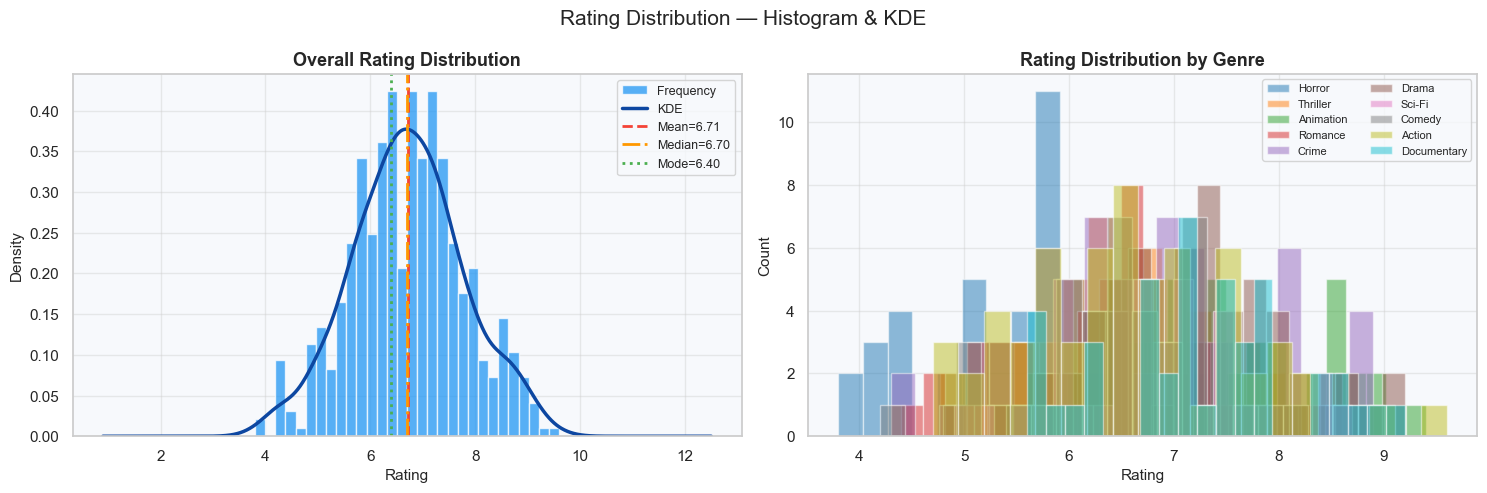

💾  Saved: histogram_rating.png


In [12]:
# ── 5.1 Histogram + KDE with Stats Lines ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Rating Distribution — Histogram & KDE', fontsize=15)

# Full distribution
ax1 = axes[0]
ax1.hist(df['rating'], bins=30, color='#2196F3', edgecolor='white',
         alpha=0.75, density=True, label='Frequency')
df['rating'].plot.kde(ax=ax1, color='#0D47A1', lw=2.5, label='KDE')

mean_v   = df['rating'].mean()
median_v = df['rating'].median()
mode_v   = float(stats.mode(df['rating'], keepdims=True).mode[0])

ax1.axvline(mean_v,   color='#F44336', lw=2, linestyle='--', label=f'Mean={mean_v:.2f}')
ax1.axvline(median_v, color='#FF9800', lw=2, linestyle='-.',  label=f'Median={median_v:.2f}')
ax1.axvline(mode_v,   color='#4CAF50', lw=2, linestyle=':',   label=f'Mode={mode_v:.2f}')
ax1.set_xlabel('Rating'); ax1.set_ylabel('Density')
ax1.set_title('Overall Rating Distribution')
ax1.legend(fontsize=9)

# Per-genre stacked histogram
ax2 = axes[1]
genre_list = df['genre'].unique()
colors_g   = plt.cm.tab10(np.linspace(0, 1, len(genre_list)))
for genre, color in zip(genre_list, colors_g):
    subset = df[df['genre'] == genre]['rating']
    ax2.hist(subset, bins=20, alpha=0.5, color=color,
             edgecolor='white', label=genre, density=False)
ax2.set_xlabel('Rating'); ax2.set_ylabel('Count')
ax2.set_title('Rating Distribution by Genre')
ax2.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('histogram_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: histogram_rating.png')

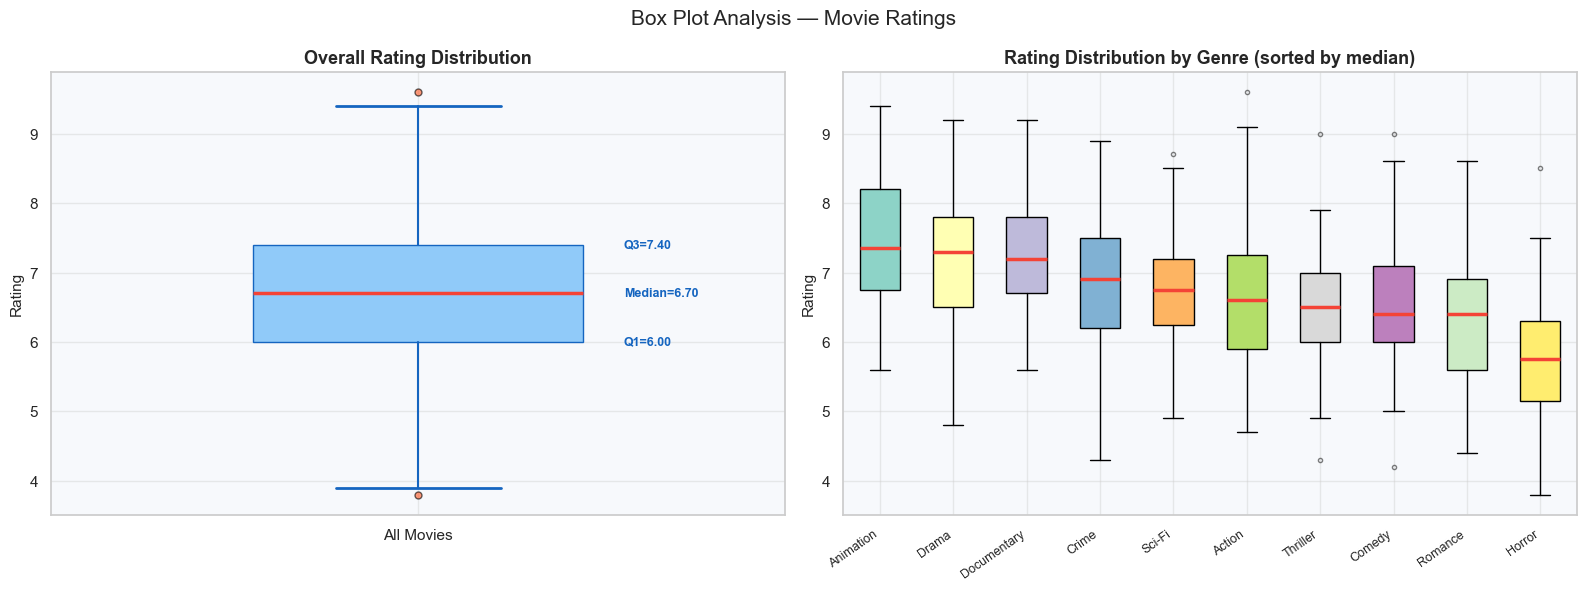

💾  Saved: boxplot_rating.png


In [13]:
# ── 5.2 Box Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Box Plot Analysis — Movie Ratings', fontsize=15)

# Overall box plot
ax1 = axes[0]
bp  = ax1.boxplot(df['rating'].dropna(), vert=True, patch_artist=True,
                  widths=0.45,
                  boxprops    =dict(facecolor='#90CAF9', color='#1565C0'),
                  medianprops =dict(color='#F44336', lw=2.5),
                  whiskerprops=dict(color='#1565C0', lw=1.5),
                  capprops    =dict(color='#1565C0', lw=2),
                  flierprops  =dict(marker='o', color='#FF5722',
                                   markerfacecolor='#FF5722', markersize=5, alpha=0.6))
ax1.set_ylabel('Rating')
ax1.set_xticklabels(['All Movies'])
ax1.set_title('Overall Rating Distribution')
# Annotate quartiles
q1, q2, q3 = df['rating'].quantile([0.25, 0.5, 0.75])
for val, label in [(q1,'Q1'), (q2,'Median'), (q3,'Q3')]:
    ax1.text(1.28, val, f'{label}={val:.2f}', va='center', fontsize=9,
             color='#1565C0', fontweight='bold')

# Box plot per genre
ax2 = axes[1]
genres_sorted = df.groupby('genre')['rating'].median().sort_values(ascending=False).index
data_by_genre = [df[df['genre'] == g]['rating'].dropna().values for g in genres_sorted]
bp2 = ax2.boxplot(data_by_genre, patch_artist=True, vert=True, widths=0.55,
                  medianprops=dict(color='#F44336', lw=2.5),
                  flierprops =dict(marker='o', markersize=3, alpha=0.5))
colors_box = plt.cm.Set3(np.linspace(0, 1, len(genres_sorted)))
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
ax2.set_xticklabels(genres_sorted, rotation=35, ha='right', fontsize=9)
ax2.set_ylabel('Rating')
ax2.set_title('Rating Distribution by Genre (sorted by median)')

plt.tight_layout()
plt.savefig('boxplot_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: boxplot_rating.png')

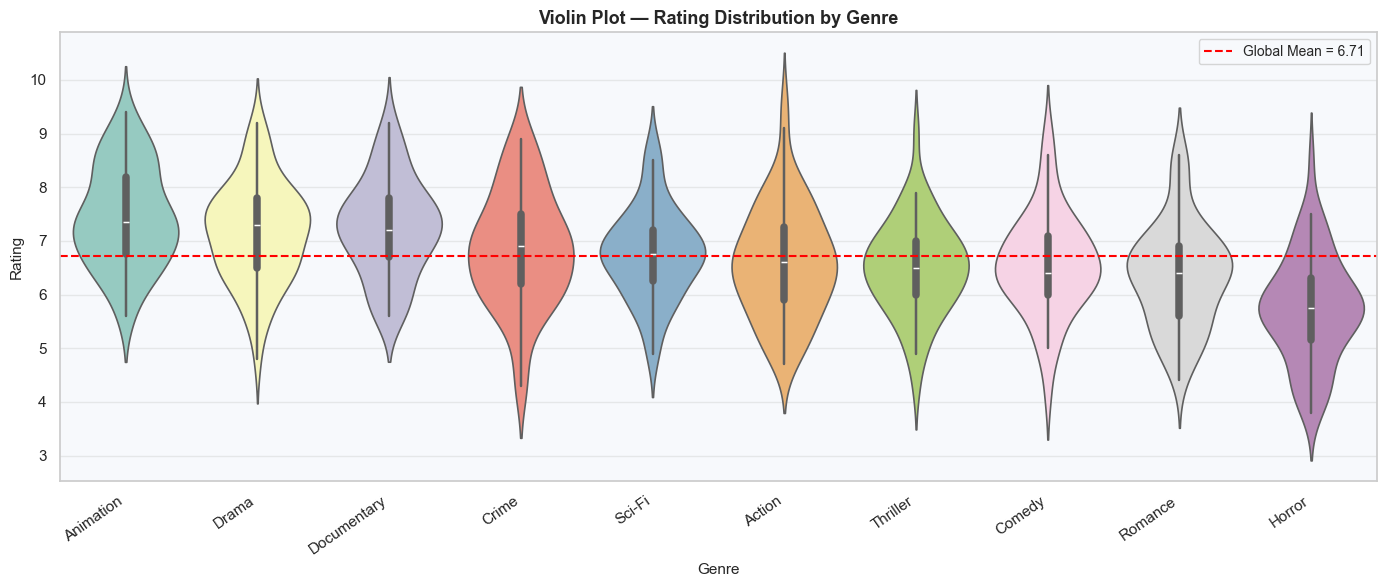

💾  Saved: violin_rating.png


In [14]:
# ── 5.3 Violin Plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df, x='genre', y='rating',
               order=genres_sorted,
               palette='Set3', inner='box', linewidth=1.2, ax=ax)
ax.axhline(df['rating'].mean(), color='red', lw=1.5,
           linestyle='--', label=f'Global Mean = {df["rating"].mean():.2f}')
ax.set_title('Violin Plot — Rating Distribution by Genre')
ax.set_xlabel('Genre'); ax.set_ylabel('Rating')
ax.set_xticklabels(genres_sorted, rotation=35, ha='right')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('violin_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: violin_rating.png')

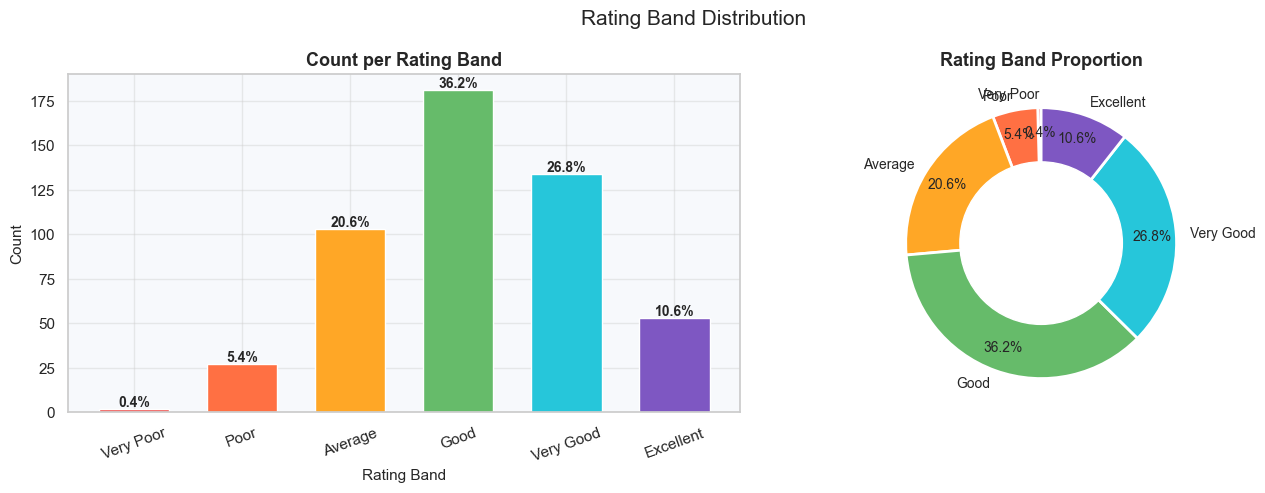

💾  Saved: rating_band_distribution.png


In [15]:
# ── 5.4 Rating Band Distribution ────────────────────────────
band_order  = ['Very Poor','Poor','Average','Good','Very Good','Excellent']
band_counts = df['rating_band'].value_counts().reindex(band_order)
band_pct    = (band_counts / band_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Band Distribution', fontsize=15)

band_colors = ['#EF5350','#FF7043','#FFA726','#66BB6A','#26C6DA','#7E57C2']

# Bar chart
bars = axes[0].bar(band_order, band_counts.values, color=band_colors,
                   edgecolor='white', width=0.65)
for bar, pct in zip(bars, band_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{pct}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Rating Band'); axes[0].set_ylabel('Count')
axes[0].set_title('Count per Rating Band')
axes[0].tick_params(axis='x', rotation=20)

# Donut chart
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[1].pie(band_counts.values, labels=band_order, colors=band_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=wedge_props, textprops={'fontsize': 10},
            pctdistance=0.82)
# Donut hole
centre_circle = plt.Circle((0,0), 0.60, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Rating Band Proportion')

plt.tight_layout()
plt.savefig('rating_band_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: rating_band_distribution.png')

---
## 6. 🏆 Top-Rated Movies & Genres

In [16]:
# ── 6.1 Top 15 Movies ────────────────────────────────────────
top_movies = df.nlargest(15, 'rating')[['title','genre','year','rating','votes','director']]
print('── Top 15 Highest-Rated Movies ───────────────────────')
top_movies.reset_index(drop=True).style \
    .background_gradient(subset=['rating'], cmap='YlGn') \
    .format({'rating': '{:.1f}', 'votes': '{:,}'})

── Top 15 Highest-Rated Movies ───────────────────────


,title,genre,year,rating,votes,director
0,The Last Dream 165,Action,2014,9.6,"64,929",Denis Villeneuve
1,The Last Moon 248,Animation,1995,9.4,"120,812",David Fincher
2,The Broken Echo 107,Drama,1996,9.2,"239,923",Denis Villeneuve
3,The Silent Path 147,Documentary,2010,9.2,"100,983",Wes Anderson
4,The Dark Dream 108,Animation,2004,9.1,"95,581",James Cameron
5,The Dark Path 449,Action,2012,9.1,"203,627",Martin Scorsese
6,The Final Echo 61,Thriller,2006,9.0,"64,528",James Cameron
7,The Broken Fire 80,Documentary,1998,9.0,"271,538",Denis Villeneuve
8,The Broken Night 175,Animation,1993,9.0,"488,449",David Fincher
9,The Silent Fire 292,Drama,2022,9.0,"43,321",James Cameron


In [17]:
# ── 6.2 Bottom 10 Movies ─────────────────────────────────────
bottom_movies = df.nsmallest(10, 'rating')[['title','genre','year','rating','votes']]
print('── Bottom 10 Lowest-Rated Movies ─────────────────────')
bottom_movies.reset_index(drop=True).style \
    .background_gradient(subset=['rating'], cmap='OrRd_r') \
    .format({'rating': '{:.1f}', 'votes': '{:,}'})

── Bottom 10 Lowest-Rated Movies ─────────────────────


,title,genre,year,rating,votes
0,The Last Moon 129,Horror,2018,3.8,"167,423"
1,The Last Storm 118,Horror,2003,3.9,"157,070"
2,The Last Shadow 218,Horror,2014,4.2,"76,756"
3,The Final Moon 262,Comedy,2005,4.2,"478,246"
4,The Dark City 322,Horror,2004,4.2,"141,405"
5,The Dark Moon 420,Horror,1993,4.2,"96,611"
6,The Burning Storm 169,Horror,2020,4.3,"431,520"
7,The Last World 213,Horror,2000,4.3,"488,663"
8,The Final Echo 231,Thriller,1992,4.3,"469,280"
9,The Broken Path 333,Crime,1991,4.3,"303,429"


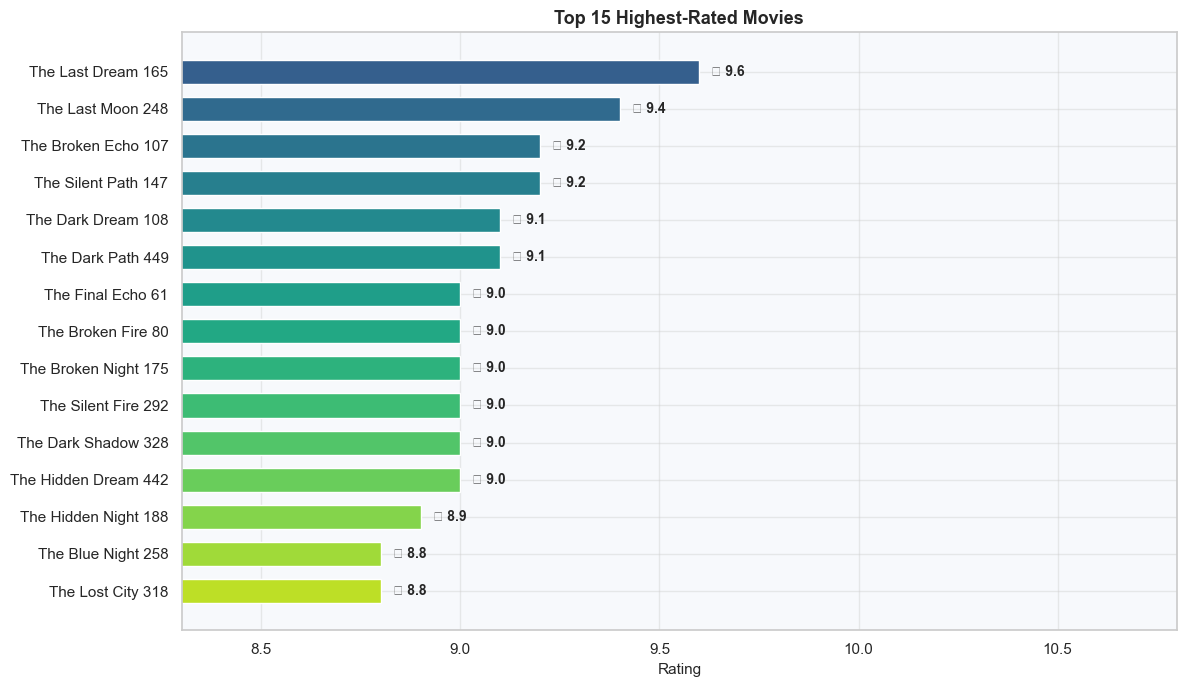

💾  Saved: top_movies.png


In [18]:
# ── 6.3 Top Movies — Horizontal Bar Chart ────────────────────
top15 = df.nlargest(15, 'rating')

fig, ax = plt.subplots(figsize=(12, 7))
colors_tm = plt.cm.viridis(np.linspace(0.3, 0.9, len(top15)))
bars = ax.barh(top15['title'], top15['rating'],
               color=colors_tm, edgecolor='white', height=0.65)
for bar, val in zip(bars, top15['rating']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'⭐ {val:.1f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_title('Top 15 Highest-Rated Movies')
ax.set_xlim([top15['rating'].min() - 0.5, 10.8])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_movies.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: top_movies.png')

In [19]:
# ── 6.4 Genre Analysis ───────────────────────────────────────
genre_analysis = df.groupby('genre').agg(
    Count          = ('rating', 'count'),
    Avg_Rating     = ('rating', 'mean'),
    Median_Rating  = ('rating', 'median'),
    Total_Votes    = ('votes',  'sum'),
    Avg_Duration   = ('duration_min', 'mean'),
).round(2).sort_values('Avg_Rating', ascending=False).reset_index()

print('── Genre Analysis Table ──────────────────────────────')
genre_analysis.style \
    .background_gradient(subset=['Avg_Rating','Median_Rating'], cmap='YlGn') \
    .background_gradient(subset=['Total_Votes'], cmap='Blues') \
    .format({'Total_Votes': '{:,}', 'Avg_Rating': '{:.2f}',
             'Median_Rating': '{:.2f}', 'Avg_Duration': '{:.1f}'})

── Genre Analysis Table ──────────────────────────────


,genre,Count,Avg_Rating,Median_Rating,Total_Votes,Avg_Duration
0,Animation,51,7.45,7.35,"10,502,607",110.2
1,Documentary,44,7.25,7.20,"9,346,040",102.3
2,Drama,57,7.16,7.30,"13,721,943",107.9
3,Crime,54,6.84,6.90,"12,664,402",106.8
4,Sci-Fi,39,6.77,6.75,"10,182,741",108.3
5,Action,62,6.60,6.60,"13,939,195",104.8
6,Comedy,41,6.57,6.40,"11,396,497",103.5
7,Thriller,48,6.50,6.50,"9,621,630",100.3
8,Romance,49,6.35,6.40,"11,517,345",107.4
9,Horror,55,5.74,5.75,"14,250,161",101.6


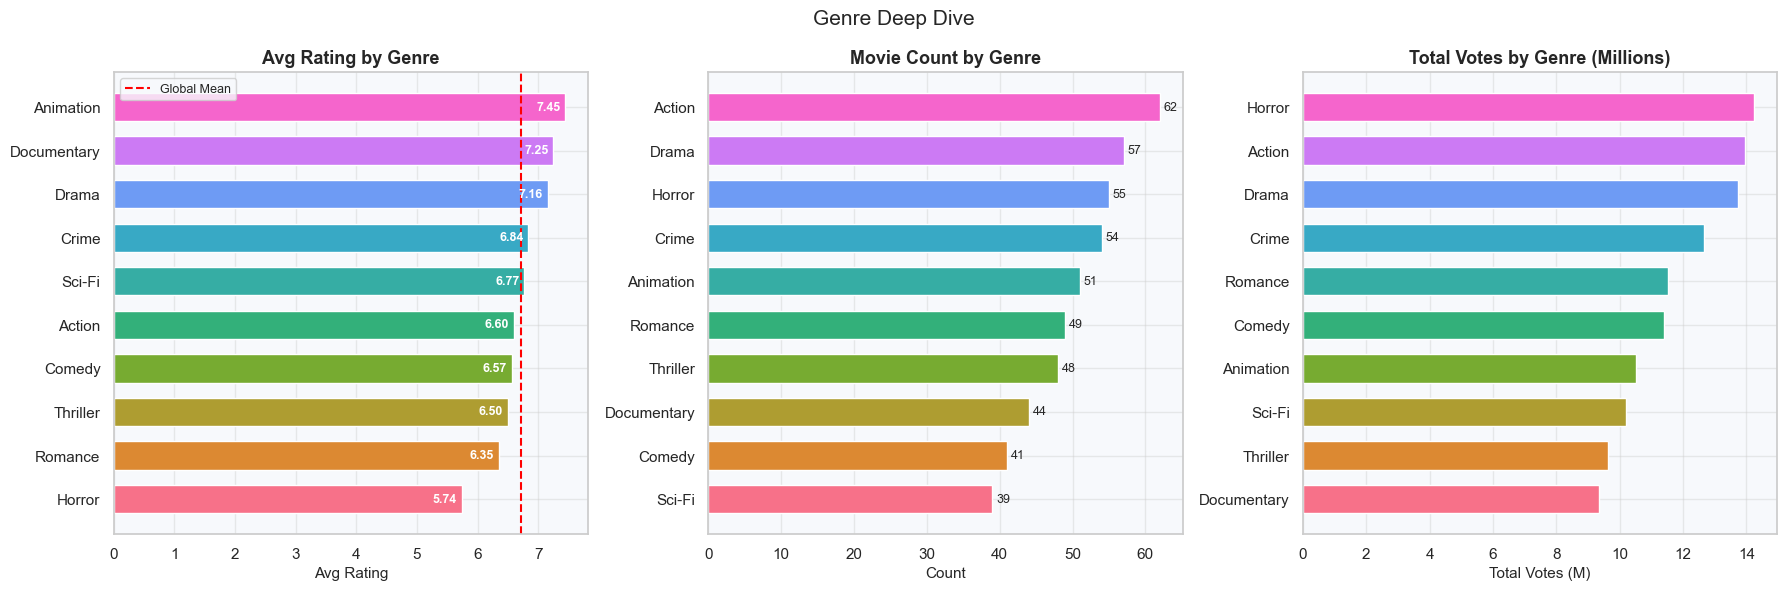

💾  Saved: genre_analysis.png


In [20]:
# ── 6.5 Genre Visualizations ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Genre Deep Dive', fontsize=15)

palette_g = sns.color_palette('husl', len(genre_analysis))

# Average rating
g_sorted = genre_analysis.sort_values('Avg_Rating')
bars = axes[0].barh(g_sorted['genre'], g_sorted['Avg_Rating'],
                    color=palette_g, edgecolor='white', height=0.65)
for bar, val in zip(bars, g_sorted['Avg_Rating']):
    axes[0].text(bar.get_width() - 0.08, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', ha='right',
                 color='white', fontweight='bold', fontsize=9)
axes[0].set_title('Avg Rating by Genre')
axes[0].set_xlabel('Avg Rating')
axes[0].axvline(df['rating'].mean(), color='red', lw=1.5,
                linestyle='--', label=f'Global Mean')
axes[0].legend(fontsize=9)

# Movie count
g_sorted2 = genre_analysis.sort_values('Count')
axes[1].barh(g_sorted2['genre'], g_sorted2['Count'],
             color=palette_g, edgecolor='white', height=0.65)
for i, val in enumerate(g_sorted2['Count']):
    axes[1].text(val + 0.5, i, str(val), va='center', fontsize=9)
axes[1].set_title('Movie Count by Genre')
axes[1].set_xlabel('Count')

# Total votes
g_sorted3 = genre_analysis.sort_values('Total_Votes')
axes[2].barh(g_sorted3['genre'], g_sorted3['Total_Votes']/1e6,
             color=palette_g, edgecolor='white', height=0.65)
axes[2].set_title('Total Votes by Genre (Millions)')
axes[2].set_xlabel('Total Votes (M)')

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: genre_analysis.png')

---
## 7. 📅 Trends Over Time

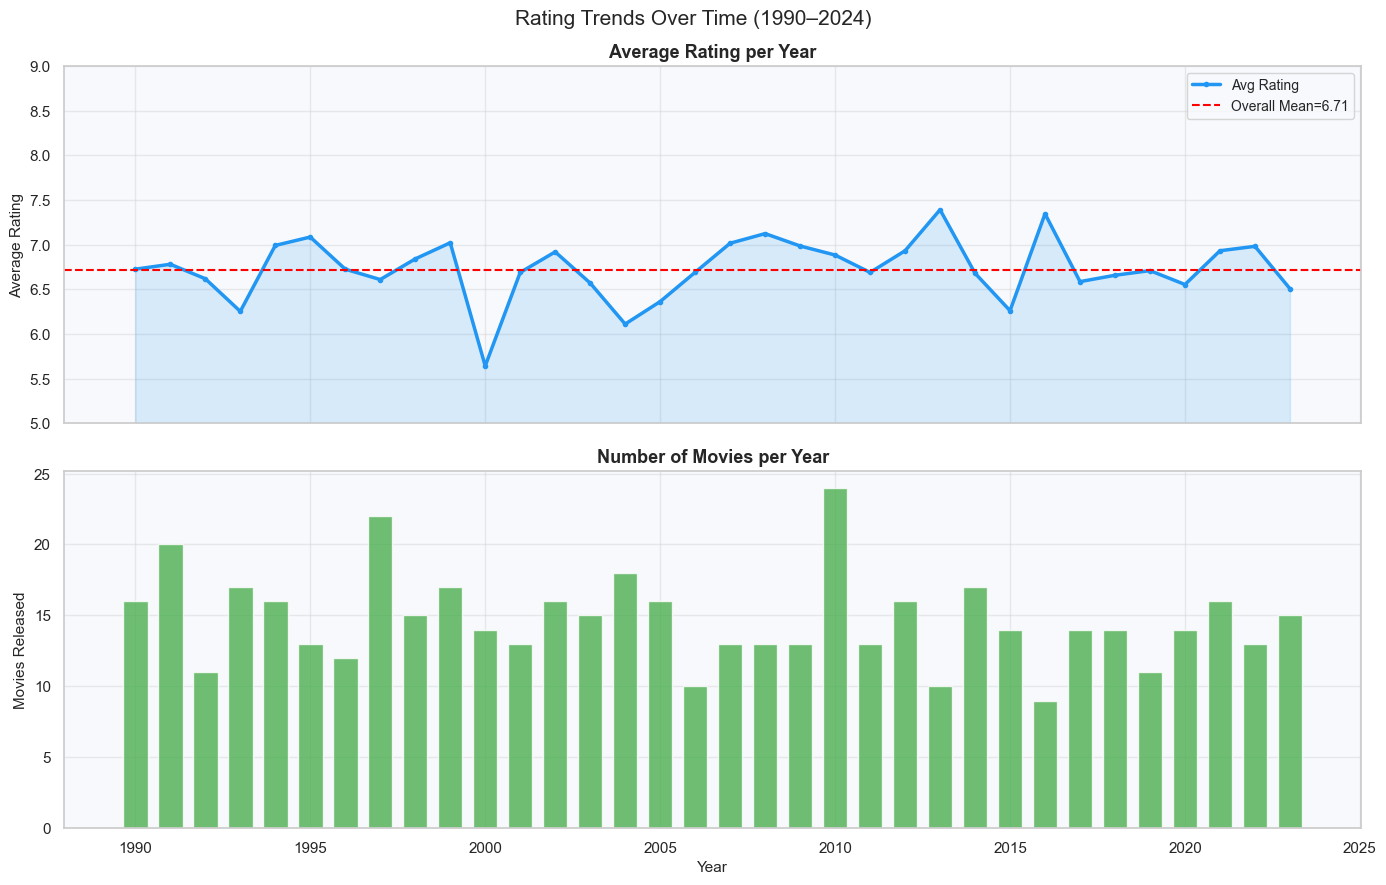

💾  Saved: rating_trends.png


In [21]:
# ── 7.1 Average Rating by Year ───────────────────────────────
yearly = df.groupby('year').agg(
    Avg_Rating = ('rating','mean'),
    Count      = ('rating','count')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Rating Trends Over Time (1990–2024)', fontsize=15)

# Line plot — avg rating
axes[0].plot(yearly['year'], yearly['Avg_Rating'],
             color='#2196F3', lw=2.5, marker='o', ms=3, label='Avg Rating')
axes[0].fill_between(yearly['year'], yearly['Avg_Rating'],
                     alpha=0.15, color='#2196F3')
axes[0].axhline(df['rating'].mean(), color='red', lw=1.5,
                linestyle='--', label=f'Overall Mean={df["rating"].mean():.2f}')
axes[0].set_ylabel('Average Rating')
axes[0].set_title('Average Rating per Year')
axes[0].legend(fontsize=10)
axes[0].set_ylim([5, 9])

# Bar chart — movie count
axes[1].bar(yearly['year'], yearly['Count'], color='#4CAF50',
            edgecolor='white', alpha=0.8, width=0.7)
axes[1].set_ylabel('Movies Released')
axes[1].set_xlabel('Year')
axes[1].set_title('Number of Movies per Year')

plt.tight_layout()
plt.savefig('rating_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: rating_trends.png')

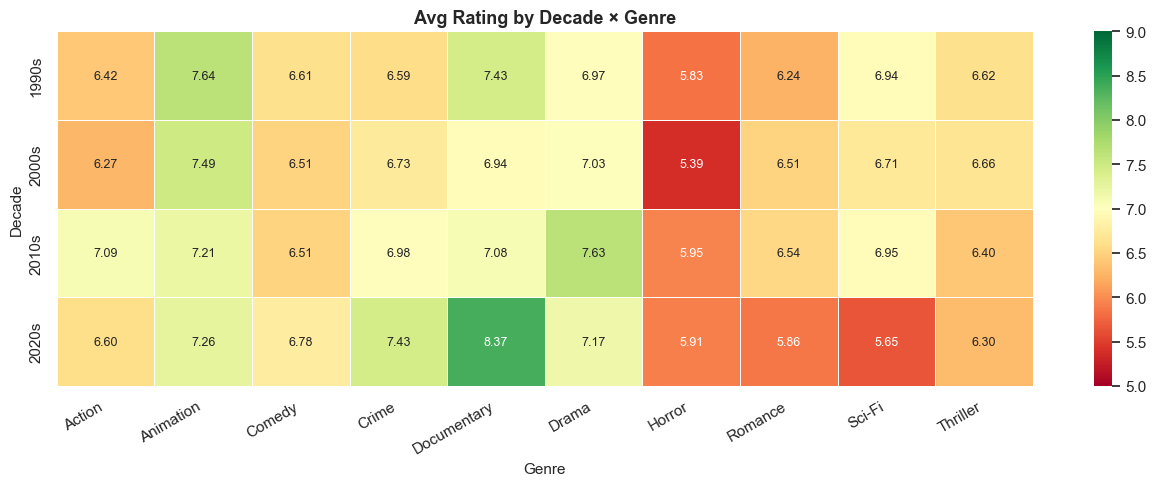

💾  Saved: decade_genre_heatmap.png


In [22]:
# ── 7.2 Decade-wise Genre Heatmap ────────────────────────────
decade_genre = df.groupby(['decade','genre'])['rating'].mean().unstack().round(2)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(decade_genre, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=5, vmax=9, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Avg Rating by Decade × Genre', fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Decade')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('decade_genre_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: decade_genre_heatmap.png')

---
## 8. 🔍 Additional Analyses

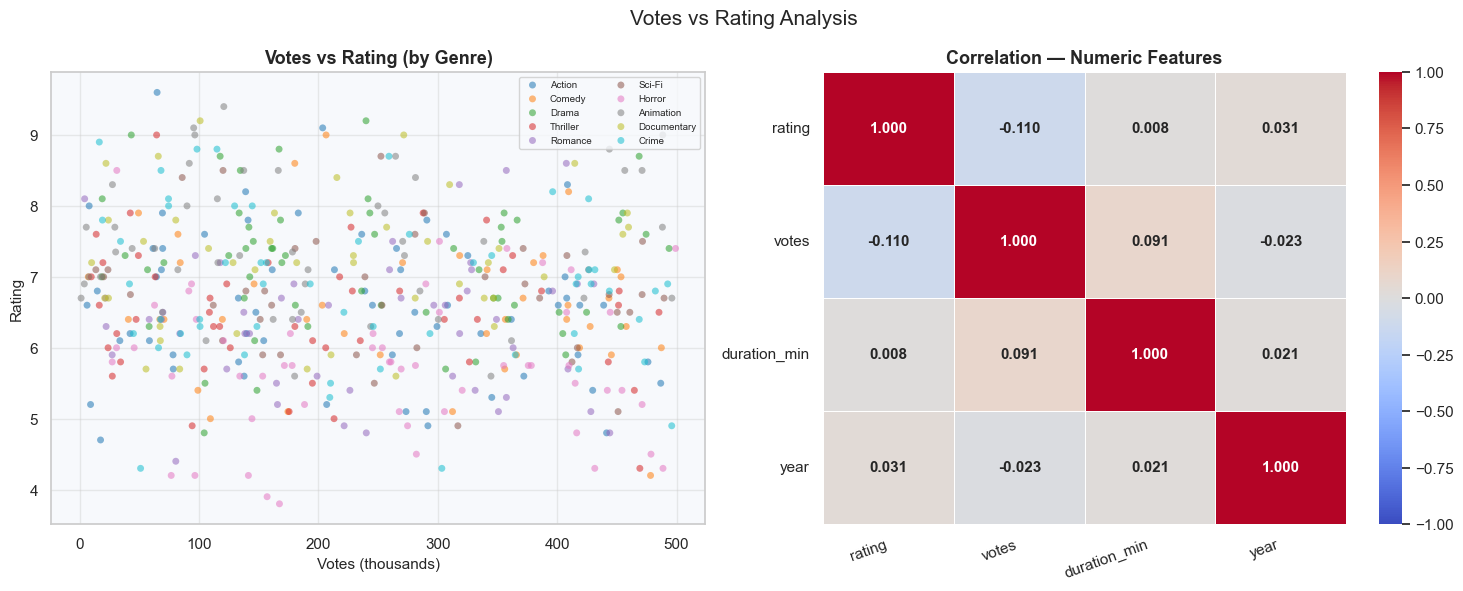

💾  Saved: votes_rating_analysis.png


In [23]:
# ── 8.1 Votes vs Rating Scatter ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Votes vs Rating Analysis', fontsize=15)

# Scatter
for genre, color in zip(GENRES, plt.cm.tab10(np.linspace(0,1,10))):
    sub = df[df['genre'] == genre]
    axes[0].scatter(sub['votes']/1000, sub['rating'], color=color,
                   label=genre, s=25, alpha=0.55, edgecolors='none')
axes[0].set_xlabel('Votes (thousands)')
axes[0].set_ylabel('Rating')
axes[0].set_title('Votes vs Rating (by Genre)')
axes[0].legend(fontsize=7, ncol=2)

# Correlation heatmap — numeric features
numeric_cols = ['rating','votes','duration_min','year']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=axes[1],
            annot_kws={'size':11,'weight':'bold'})
axes[1].set_title('Correlation — Numeric Features')
axes[1].set_xticklabels(numeric_cols, rotation=20, ha='right')
axes[1].set_yticklabels(numeric_cols, rotation=0)

plt.tight_layout()
plt.savefig('votes_rating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: votes_rating_analysis.png')

In [24]:
# ── 8.2 Top Directors ────────────────────────────────────────
director_stats = df.groupby('director').agg(
    Movies     = ('title',  'count'),
    Avg_Rating = ('rating', 'mean'),
    Avg_Votes  = ('votes',  'mean'),
).round(2).sort_values('Avg_Rating', ascending=False)

print('── Director Leaderboard ──────────────────────────────')
director_stats.style \
    .background_gradient(subset=['Avg_Rating'], cmap='YlGn') \
    .format({'Avg_Votes': '{:,.0f}'})

── Director Leaderboard ──────────────────────────────


,Movies,Avg_Rating,Avg_Votes
director,,,
Christopher Nolan,53,6.890000,"252,455"
Martin Scorsese,46,6.830000,"188,210"
Denis Villeneuve,56,6.780000,"223,761"
Steven Spielberg,45,6.720000,"240,506"
Wes Anderson,49,6.690000,"216,989"
James Cameron,48,6.680000,"247,259"
Ridley Scott,52,6.660000,"235,644"
Peter Jackson,48,6.660000,"251,571"
Quentin Tarantino,58,6.660000,"229,261"


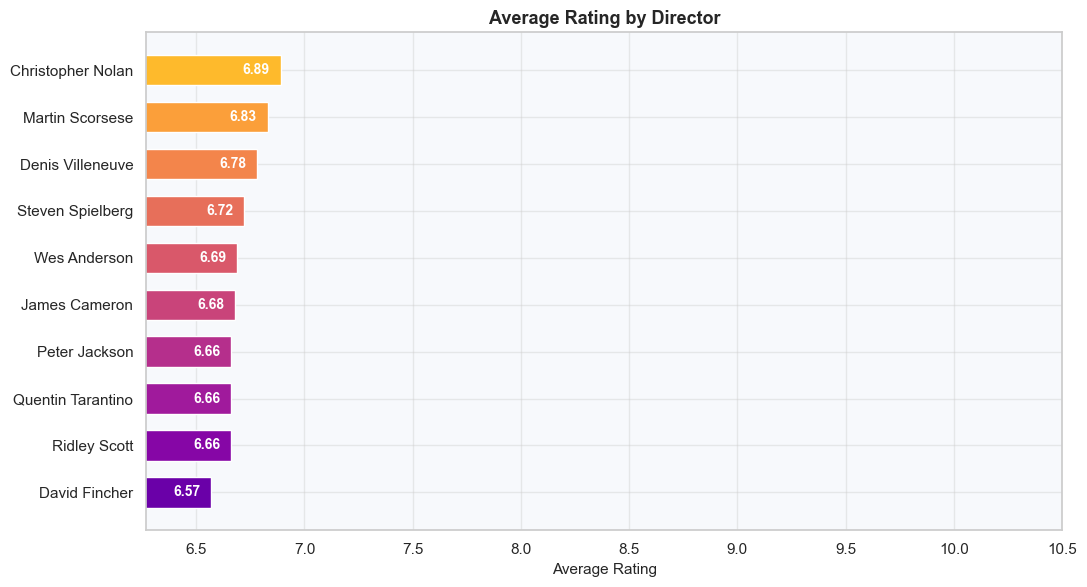

💾  Saved: director_ratings.png


In [25]:
# ── 8.3 Director Bar Chart ───────────────────────────────────
dir_sorted = director_stats.sort_values('Avg_Rating')
fig, ax    = plt.subplots(figsize=(11, 6))
colors_dir = plt.cm.plasma(np.linspace(0.2, 0.85, len(dir_sorted)))
bars = ax.barh(dir_sorted.index, dir_sorted['Avg_Rating'],
               color=colors_dir, edgecolor='white', height=0.65)
for bar, val in zip(bars, dir_sorted['Avg_Rating']):
    ax.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)
ax.set_xlabel('Average Rating')
ax.set_title('Average Rating by Director')
ax.set_xlim([dir_sorted['Avg_Rating'].min() - 0.3, 10.5])
plt.tight_layout()
plt.savefig('director_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: director_ratings.png')

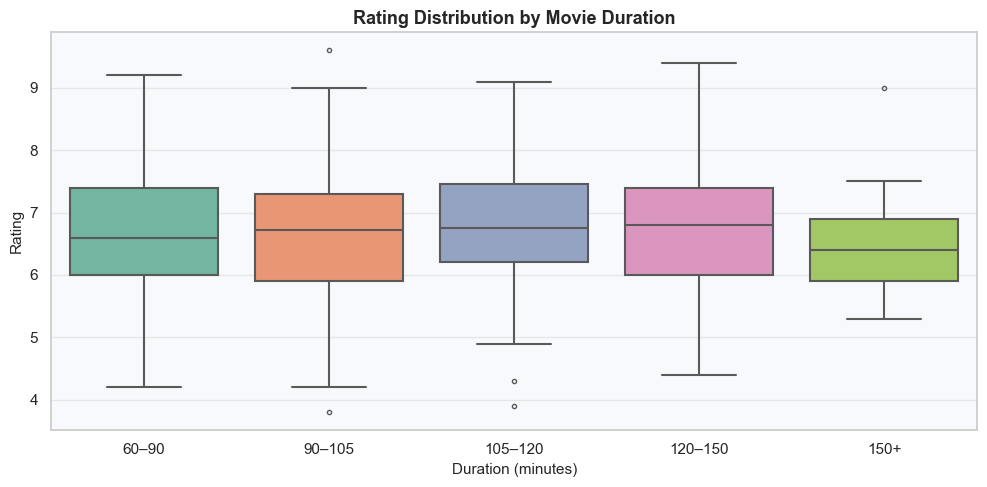

💾  Saved: duration_rating.png


In [26]:
# ── 8.4 Duration vs Rating ───────────────────────────────────
df['duration_bin'] = pd.cut(df['duration_min'],
                             bins=[60,90,105,120,150,210],
                             labels=['60–90','90–105','105–120','120–150','150+'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='duration_bin', y='rating',
            palette='Set2', ax=ax, linewidth=1.5, fliersize=3)
ax.set_title('Rating Distribution by Movie Duration')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Rating')
plt.tight_layout()
plt.savefig('duration_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾  Saved: duration_rating.png')

## 9. 🖥️ Summary Dashboard


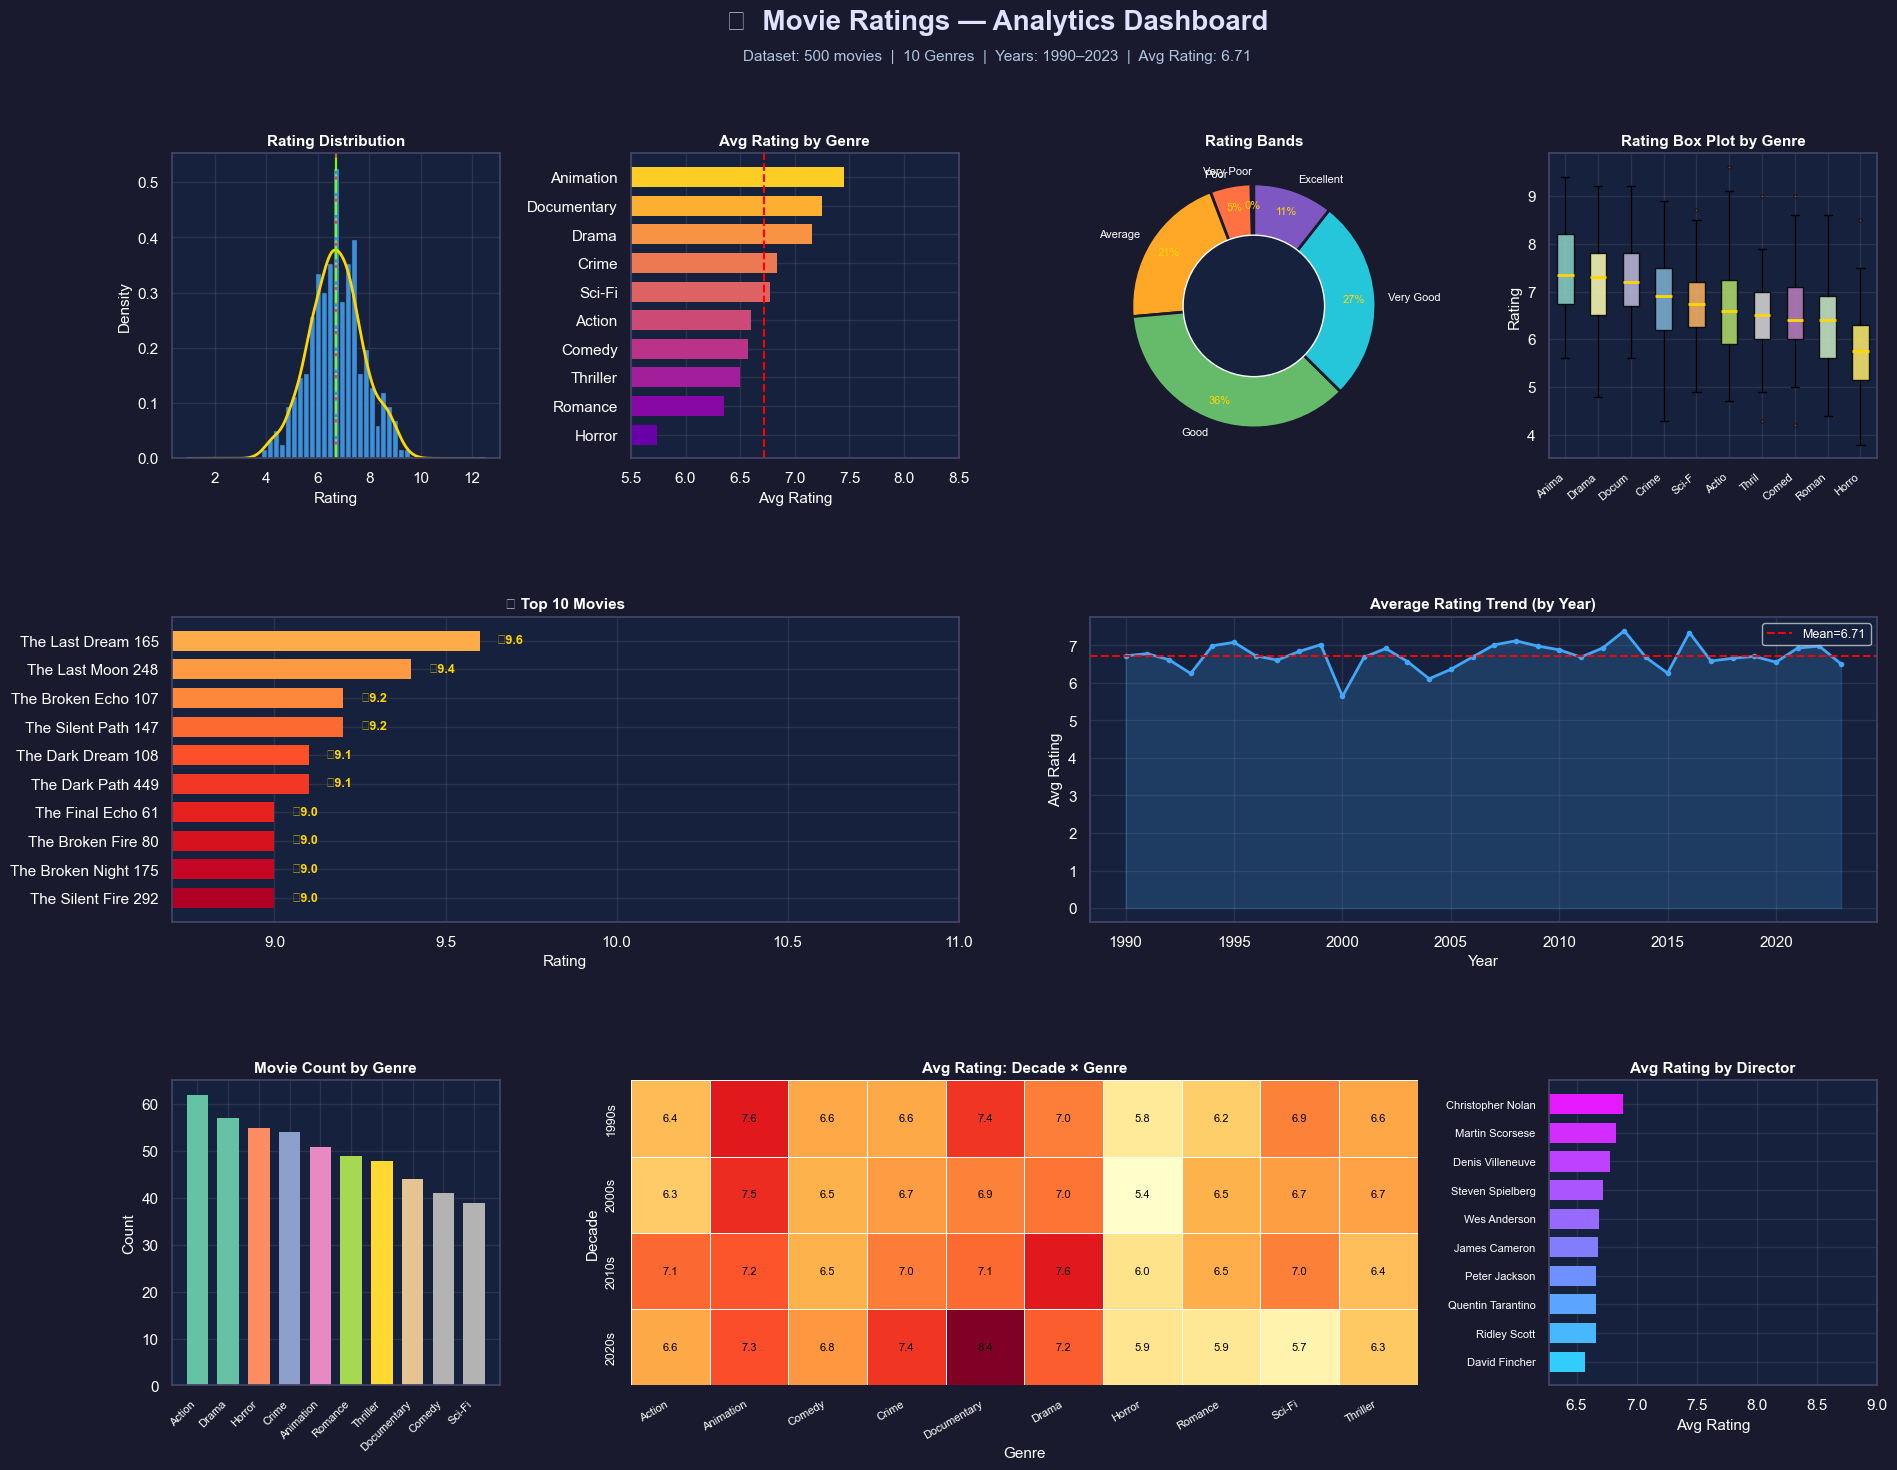

💾  Saved: movie_dashboard.png


In [27]:
fig = plt.figure(figsize=(22, 16))
fig.patch.set_facecolor('#1a1a2e')     # dark background
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.52, wspace=0.4)

DARK_AX = '#16213e'
TEXT_C  = 'white'

def style_ax(ax, title=''):
    ax.set_facecolor(DARK_AX)
    ax.tick_params(colors=TEXT_C)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    ax.title.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')
    if title:
        ax.set_title(title, color=TEXT_C, fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.2, color='gray')

# ── Title Block ──────────────────────────────────────────────
fig.text(0.5, 0.97, '🎬  Movie Ratings — Analytics Dashboard',
         ha='center', va='top', fontsize=20, fontweight='bold',
         color='#E0E0FF')
fig.text(0.5, 0.945,
         f'Dataset: {len(df)} movies  |  {len(GENRES)} Genres  |  '
         f'Years: {df["year"].min()}–{df["year"].max()}  |  '
         f'Avg Rating: {df["rating"].mean():.2f}',
         ha='center', va='top', fontsize=11, color='#B0C4DE')

# ── Plot 1 : Histogram ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['rating'], bins=25, color='#42A5F5', edgecolor='#1a1a2e',
         alpha=0.85, density=True)
df['rating'].plot.kde(ax=ax1, color='#FFD700', lw=2)
ax1.axvline(mean_v,   color='#F44336', lw=1.5, linestyle='--')
ax1.axvline(median_v, color='#76FF03', lw=1.5, linestyle='-.')
style_ax(ax1, 'Rating Distribution')
ax1.set_xlabel('Rating'); ax1.set_ylabel('Density')

# ── Plot 2 : Genre Avg Rating ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
g_s = genre_analysis.sort_values('Avg_Rating')
clrs = plt.cm.plasma(np.linspace(0.2, 0.9, len(g_s)))
ax2.barh(g_s['genre'], g_s['Avg_Rating'], color=clrs,
         edgecolor='none', height=0.7)
ax2.axvline(df['rating'].mean(), color='red', lw=1.5, linestyle='--')
style_ax(ax2, 'Avg Rating by Genre')
ax2.set_xlabel('Avg Rating')
ax2.set_xlim([5.5, 8.5])

# ── Plot 3 : Rating Band Donut ───────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(DARK_AX)
wedges, texts, autotexts = ax3.pie(
    band_counts.values, labels=band_order,
    colors=band_colors, autopct='%1.0f%%',
    startangle=90, wedgeprops={'edgecolor':'#1a1a2e','linewidth':2},
    textprops={'color': TEXT_C, 'fontsize': 8},
    pctdistance=0.82
)
for at in autotexts: at.set_color('#FFD700'); at.set_fontsize(8)
centre = plt.Circle((0,0), 0.58, fc=DARK_AX)
ax3.add_artist(centre)
ax3.set_title('Rating Bands', color=TEXT_C, fontweight='bold', fontsize=11)

# ── Plot 4 : Box Plot by Genre ───────────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
box_data = [df[df['genre']==g]['rating'].values for g in genres_sorted]
bp = ax4.boxplot(box_data, patch_artist=True,
                 medianprops=dict(color='#FFD700', lw=2),
                 flierprops =dict(marker='o', markersize=2,
                                  markerfacecolor='#FF5722', alpha=0.5))
box_clrs = plt.cm.Set3(np.linspace(0,1,len(genres_sorted)))
for patch, c in zip(bp['boxes'], box_clrs):
    patch.set_facecolor(c); patch.set_alpha(0.85)
ax4.set_xticklabels([g[:5] for g in genres_sorted],
                    rotation=40, ha='right', color=TEXT_C, fontsize=8)
style_ax(ax4, 'Rating Box Plot by Genre')
ax4.set_ylabel('Rating')

# ── Plot 5 : Top 10 Movies ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, :2])
top10 = df.nlargest(10, 'rating')
clrs5 = plt.cm.YlOrRd(np.linspace(0.4, 0.9, 10))
bars5 = ax5.barh(top10['title'], top10['rating'],
                 color=clrs5, edgecolor='none', height=0.7)
for bar, val in zip(bars5, top10['rating']):
    ax5.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'⭐{val:.1f}', va='center',
             color='#FFD700', fontweight='bold', fontsize=9)
ax5.invert_yaxis()
ax5.set_xlim([top10['rating'].min() - 0.3, 11.0])
style_ax(ax5, '🏆 Top 10 Movies')
ax5.set_xlabel('Rating')

# ── Plot 6 : Rating Trend Over Years ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2:])
ax6.plot(yearly['year'], yearly['Avg_Rating'],
         color='#42A5F5', lw=2, marker='o', ms=3)
ax6.fill_between(yearly['year'], yearly['Avg_Rating'],
                 alpha=0.2, color='#42A5F5')
ax6.axhline(df['rating'].mean(), color='red', lw=1.5,
            linestyle='--', label=f'Mean={df["rating"].mean():.2f}')
ax6.legend(fontsize=9, facecolor=DARK_AX, labelcolor=TEXT_C)
style_ax(ax6, 'Average Rating Trend (by Year)')
ax6.set_xlabel('Year'); ax6.set_ylabel('Avg Rating')

# ── Plot 7 : Genre Count ─────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
gc  = df['genre'].value_counts()
clrs7 = plt.cm.Set2(np.linspace(0,1,len(gc)))
ax7.bar(gc.index, gc.values, color=clrs7, edgecolor='none', width=0.7)
style_ax(ax7, 'Movie Count by Genre')
ax7.set_xticklabels(gc.index, rotation=45, ha='right',
                    color=TEXT_C, fontsize=8)
ax7.set_ylabel('Count')

# ── Plot 8 : Decade Heatmap ───────────────────────────────────
ax8 = fig.add_subplot(gs[2, 1:3])
ax8.set_facecolor(DARK_AX)
sns.heatmap(decade_genre, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax8, cbar=False,
            annot_kws={'size':8, 'color':'black'})
ax8.set_title('Avg Rating: Decade × Genre', color=TEXT_C,
              fontweight='bold', fontsize=11)
ax8.set_xticklabels(ax8.get_xticklabels(),
                    rotation=30, ha='right', color=TEXT_C, fontsize=8)
ax8.set_yticklabels(ax8.get_yticklabels(), color=TEXT_C, fontsize=9)
ax8.set_xlabel('Genre', color=TEXT_C)
ax8.set_ylabel('Decade', color=TEXT_C)

# ── Plot 9 : Director Avg Rating ─────────────────────────────
ax9 = fig.add_subplot(gs[2, 3])
d_s = director_stats.sort_values('Avg_Rating')
clrs9 = plt.cm.cool(np.linspace(0.2, 0.9, len(d_s)))
ax9.barh(d_s.index, d_s['Avg_Rating'], color=clrs9,
         edgecolor='none', height=0.7)
style_ax(ax9, 'Avg Rating by Director')
ax9.set_xlabel('Avg Rating')
ax9.set_xlim([d_s['Avg_Rating'].min() - 0.3, 9])
ax9.tick_params(axis='y', labelsize=8)

plt.savefig('movie_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('💾  Saved: movie_dashboard.png')

---
## 10. 📋 Final Summary Report

In [28]:
top1    = df.nlargest(1, 'rating').iloc[0]
best_g  = genre_analysis.iloc[0]
best_d  = director_stats.index[0]

print('=' * 65)
print('       🎬  MOVIE RATINGS — FINAL ANALYSIS REPORT')
print('=' * 65)
print(f'  Total Movies        : {len(df)}')
print(f'  Genres              : {len(GENRES)}')
print(f'  Year Range          : {df["year"].min()} – {df["year"].max()}')
print()
print('── Rating Statistics ─────────────────────────────────')
print(f'  Mean   Rating       : {df["rating"].mean():.3f}')
print(f'  Median Rating       : {df["rating"].median():.3f}')
print(f'  Mode   Rating       : {mode_v:.1f}')
print(f'  Std Dev             : {df["rating"].std():.3f}')
print(f'  Range               : {df["rating"].min():.1f} – {df["rating"].max():.1f}')
print()
print('── Top Performers ────────────────────────────────────')
print(f'  🏆 Best Movie       : {top1["title"]} ({top1["rating"]:.1f})')
print(f'  🎭 Best Genre       : {best_g["genre"]} (avg {best_g["Avg_Rating"]:.2f})')
print(f'  🎬 Best Director    : {best_d} (avg {director_stats.loc[best_d,"Avg_Rating"]:.2f})')
print()
print('── Saved Plots ───────────────────────────────────────')
saved = [
    'histogram_rating.png','boxplot_rating.png','violin_rating.png',
    'rating_band_distribution.png','top_movies.png','genre_analysis.png',
    'rating_trends.png','decade_genre_heatmap.png',
    'votes_rating_analysis.png','director_ratings.png',
    'duration_rating.png','movie_dashboard.png'
]
for f in saved:
    print(f'  • {f}')
print('=' * 65)

       🎬  MOVIE RATINGS — FINAL ANALYSIS REPORT
  Total Movies        : 500
  Genres              : 10
  Year Range          : 1990 – 2023

── Rating Statistics ─────────────────────────────────
  Mean   Rating       : 6.715
  Median Rating       : 6.700
  Mode   Rating       : 6.4
  Std Dev             : 1.066
  Range               : 3.8 – 9.6

── Top Performers ────────────────────────────────────
  🏆 Best Movie       : The Last Dream 165 (9.6)
  🎭 Best Genre       : Animation (avg 7.45)
  🎬 Best Director    : Christopher Nolan (avg 6.89)

── Saved Plots ───────────────────────────────────────
  • histogram_rating.png
  • boxplot_rating.png
  • violin_rating.png
  • rating_band_distribution.png
  • top_movies.png
  • genre_analysis.png
  • rating_trends.png
  • decade_genre_heatmap.png
  • votes_rating_analysis.png
  • director_ratings.png
  • duration_rating.png
  • movie_dashboard.png


---
### 📝 Plot & Section Reference

| Section | What it shows |
|---------|---------------|
| **Histogram + KDE** | Overall rating shape with Mean / Median / Mode lines |
| **Box Plot** | IQR, median, whiskers & outliers — overall and per genre |
| **Violin Plot** | Density + box stats combined per genre |
| **Rating Band Donut** | % of movies in each quality tier |
| **Top Movies Bar** | Horizontal ranking of the 15 highest-rated films |
| **Genre Analysis** | Avg rating, count, total votes, avg duration |
| **Yearly Trend** | Rating drift over time + annual release volume |
| **Decade × Genre Heatmap** | Which genre was best in each decade |
| **Votes vs Rating Scatter** | Popularity vs quality correlation |
| **Director Leaderboard** | Average rating per director |
| **Duration vs Rating** | Do longer films get rated higher? |
| **Dashboard (dark theme)** | All-in-one executive summary (9 panels) |

> 💡 **To use your own data:** Replace Section 2 with `df = pd.read_csv('movies.csv')` and rename columns to match: `title`, `genre`, `year`, `rating`, `votes`, `duration_min`, `director`